dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters', 'bounds', 'maxit'])


dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters', 'bounds', 'maxit'])
dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters', 'bounds', 'maxit'])


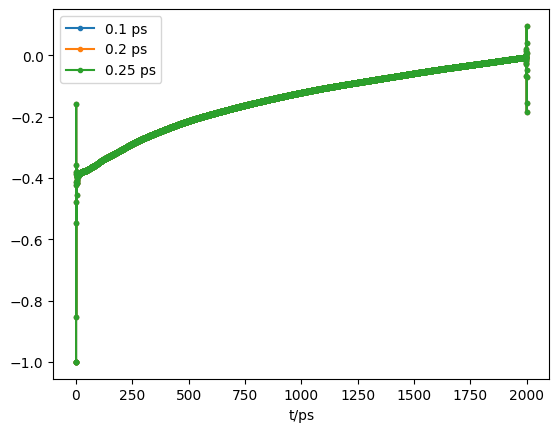

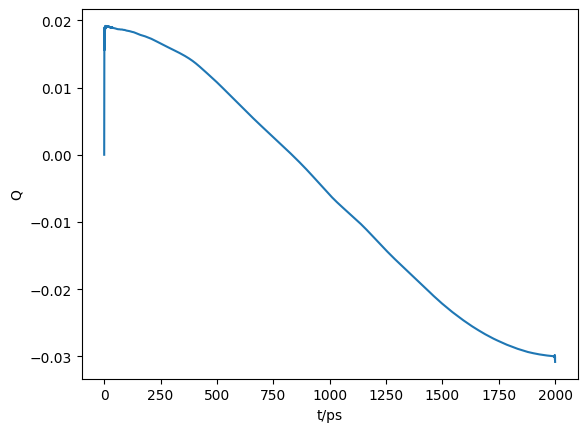

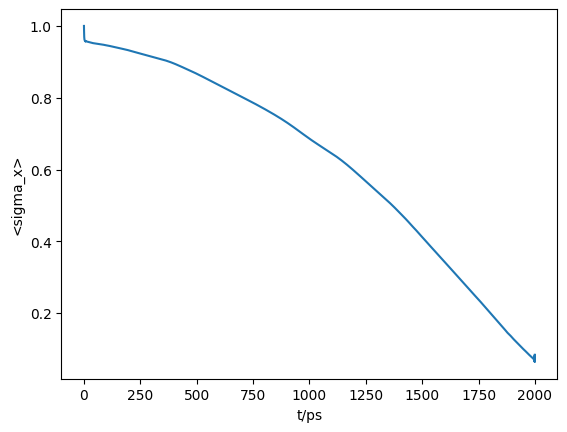

0.0308180744886131


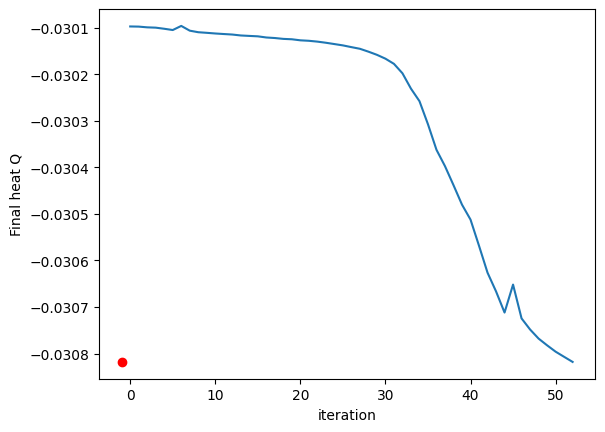

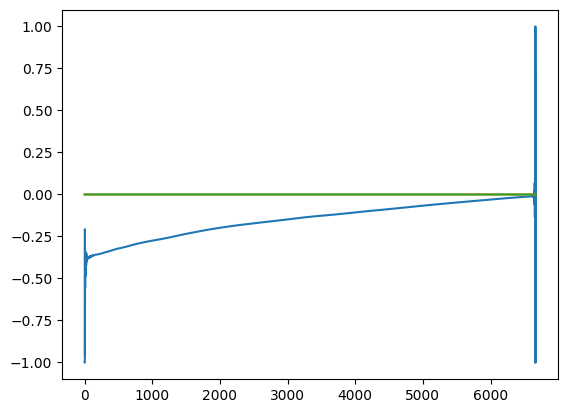

In [4]:
import dill
import matplotlib.pyplot as plt
import numpy as np
import oqupy.operators as op


for dt in [0.1,0.2,0.25]:
    with open('results/zero_control/conv_checks/dt=0.2_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0_headstart/2000ps', 'rb') as f: #'results/zero_control/conv_checks/dt=0.2_ps=-8.0_tcut=500_x=5.0_y=0.0_z=0.0/500ps'
        opt_dict = dill.load(f)
    print(opt_dict.keys())

    hx = opt_dict['result'].x[0::3]
    #hy = opt_dict['result'].x[1::3]
    #hz = opt_dict['result'].x[2::3]
    hx = opt_dict['log'][20]['x'][:,0::3][0::2]

    t_prot = 2000
    num_steps = len(hx)
    times=np.linspace(0,t_prot,num_steps+1)
    heats=opt_dict['log'][-1]['full heats']
    dynamics=opt_dict['fidelitygrad']['dynamics']

    plt.plot(times[:-1],hx,label='{0} ps'.format(dt),marker='.')
    #plt.plot(times[:-1],hy,label='hy')
    #plt.plot(times[:-1],hz,label='hz')
#plt.xlim(0,5)
plt.xlabel('t/ps')
plt.legend()
plt.show()

plt.plot(times,heats)
#plt.xlim(0,50)
plt.xlabel('t/ps')
plt.ylabel('Q')
plt.show()
plt.plot(times,[np.trace(states@op.sigma("x")) for states in dynamics.states])
plt.xlabel('t/ps')
plt.ylabel('<sigma_x>')
plt.show()

current_iteration=-1
num_its=np.shape(opt_dict['log'])[-1]
fin_heats=[entry['full heats'][-1] for entry in opt_dict['log']]
print(max(np.abs(fin_heats)))
plt.plot(range(num_its),fin_heats)
plt.plot(current_iteration,fin_heats[current_iteration],'ro')
plt.xlabel('iteration')
plt.ylabel('Final heat Q')
plt.show()

control=opt_dict['log'][-1]['x']
plt.plot(control[0::3])
plt.show()

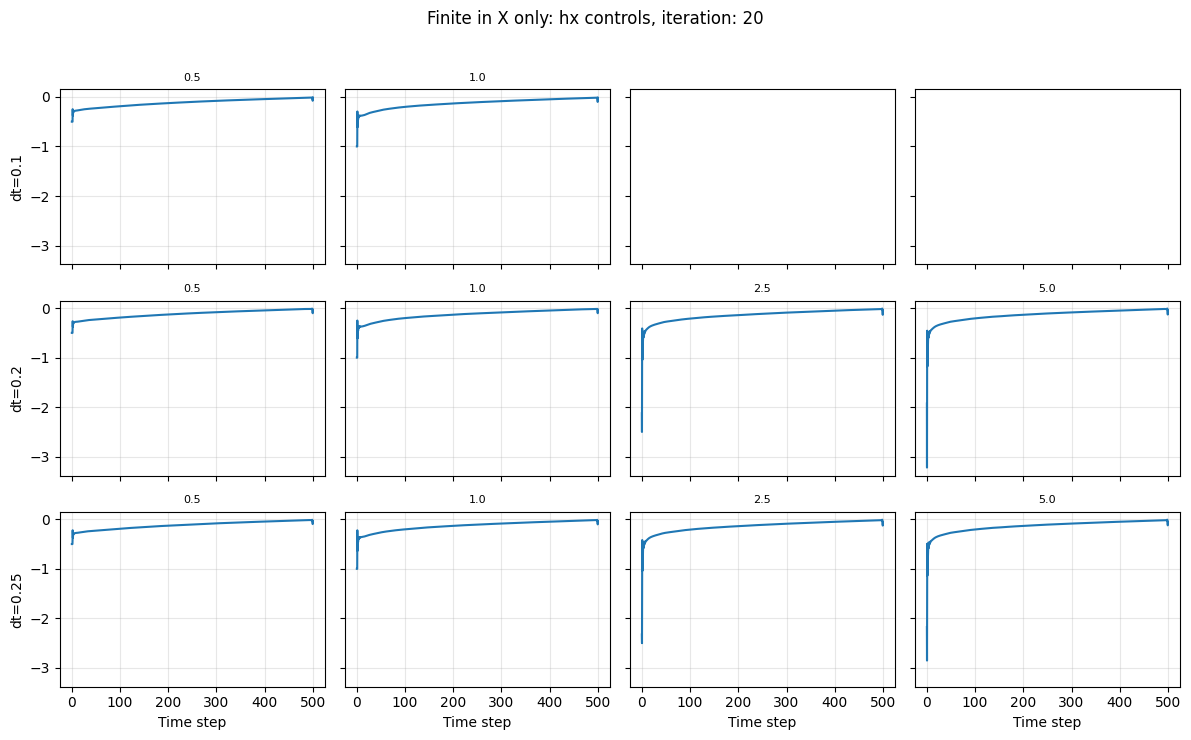

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_920/2818310917.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


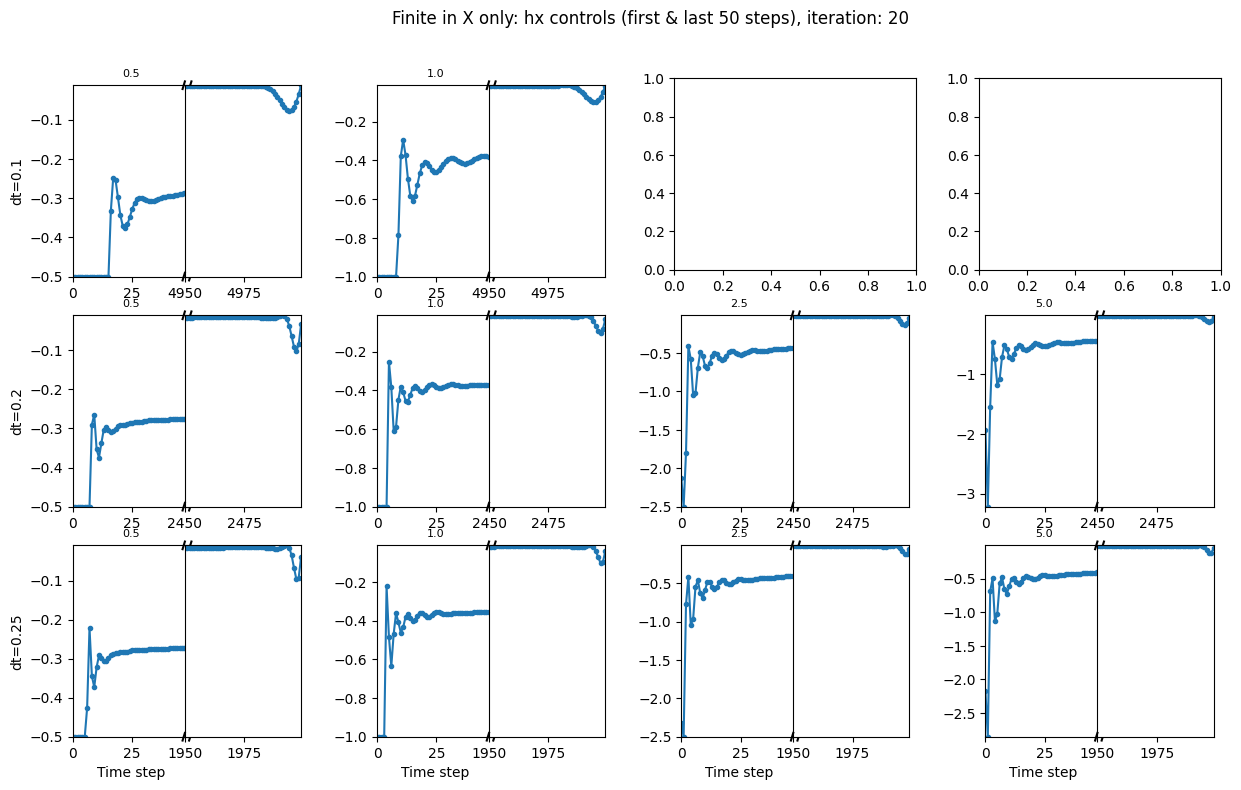

In [8]:
import os
import dill
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


base_dir = "results/zero_control/conv_checks"

folders = [
    "dt=0.2_ps=-8.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "dt=0.2_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0",
    "dt=0.25_ps=-8.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "dt=0.25_ps=-8.0_tcut=500_x=0.5_y=0.5_z=0.5",
    "dt=0.25_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0",
    "dt=0.25_ps=-8.0_tcut=500_x=2.5_y=0.0_z=0.0",
    "dt=0.25_ps=-8.0_tcut=500_x=5.0_y=0.0_z=0.0",
    "dt=0.2_ps=-8.0_tcut=500_x=2.5_y=0.0_z=0.0",
    "dt=0.2_ps=-8.0_tcut=500_x=5.0_y=0.0_z=0.0",
    "dt=0.1_ps=-8.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "dt=0.1_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0"
]

x_only = {}
xyz_all = {}

def load_opt_dict(path):
    try:
        with open(path, "rb") as f:
            return dill.load(f)
    except Exception as e:
        print(f"Failed to load {path}: {e}")
        return None
    
x_only = {}
xyz_all = {}
for folder in folders:
    parts = folder.split("_")
    dt = float(parts[0].split("=")[1])
    x = float(parts[-3].split("=")[1])
    y = float(parts[-2].split("=")[1])
    z = float(parts[-1].split("=")[1])
    
    if y == 0 and z == 0 and x > 0:
        x_only.setdefault(dt, []).append((x, folder))
    elif x > 0 and y > 0 and z > 0:
        xyz_all.setdefault(dt, []).append(((x, y, z), folder))

def load_opt_dict(path):
    try:
        with open(path, "rb") as f:
            return dill.load(f)
    except Exception as e:
        print(f"Failed to load {path}: {e}")
        return None

def get_controls(folder,iteration=-1):
    path = os.path.join(base_dir, folder, "500ps")
    opt_dict = load_opt_dict(path)
    if opt_dict is None:
        return None, None, None

    if iteration==-1:
        x_ctrl = opt_dict["result"].x[0::3]
        y_ctrl = opt_dict["result"].x[1::3]
        z_ctrl = opt_dict["result"].x[2::3]
    else:
        # accidently saved controls over half time-steps rather than full - just skip every second step
        x_ctrl = opt_dict["log"][iteration]["x"][:,0::3][0::2]
        y_ctrl = opt_dict["log"][iteration]["x"][:,1::3][0::2]
        z_ctrl = opt_dict["log"][iteration]["x"][:,2::3][0::2]
    return x_ctrl, y_ctrl, z_ctrl


def plot_control_grid(control_dict, title_prefix, control_label="hx",iteration=-1):
    dts = sorted(control_dict.keys())
    
    # determine number of columns for largest number of bounds per dt
    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols,2.5*nrows), sharex=True, sharey=True)
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt], key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):
            

            hx, hy, hz = get_controls(folder,iteration)

            t=np.linspace(0,t_prot,len(hx))  

            ax = axes[i,j]
            if hx is None:
                continue
            if control_label == "hx":
                ax.plot(t,hx)
            elif control_label == "hy":
                ax.plot(t,hy)
            elif control_label == "hz":
                ax.plot(t,hz)
            ax.set_title(f"{bounds}", fontsize=8)
            if i == nrows-1:
                ax.set_xlabel("Time step")
            if j == 0:
                ax.set_ylabel(f"dt={dt}")
            ax.grid(alpha=0.3)
    plt.suptitle(f"{title_prefix}: {control_label} controls, iteration: {iteration}")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def plot_control_grid_zoom(control_dict, title_prefix, control_label="hx", n_edge=10,iteration=-1):
    dts = sorted(control_dict.keys())
    
    # First, find global y-axis limits
    all_y = []
    for dt in dts:
        for bounds, folder in control_dict[dt]:

            hx, hy, hz = get_controls(folder,iteration)

            if hx is None:
                continue
            ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
            yplot = np.concatenate([ydata[:n_edge], ydata[-n_edge:]])
            all_y.append(yplot)
    all_y = np.concatenate(all_y)
    global_ymin, global_ymax = np.min(all_y), np.max(all_y)
    
    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols,2.5*nrows), sharey=False)
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt], key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):
            

            hx, hy, hz = get_controls(folder,iteration)

            ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
            N = len(ydata)
            """
            ax = axes[i,j]
            if hx is None:
                continue
            

            

            yplot = np.concatenate([ydata[:n_edge], ydata[-n_edge:]])
            xplot = np.arange(len(yplot))
            
            ax.plot(xplot, yplot, color='C0',marker='.')
            
            # vertical lines 
            for xi in range(len(xplot)):
                ax.axvline(x=xi, color='gray', alpha=0.3, linewidth=0.5)
            

            #y_min, y_max = np.min(yplot), np.max(yplot)
            y_min,y_max=-bounds,bounds
            ax.axhline(y_min, color='red', linestyle='--', alpha=0.7)
            ax.axhline(y_max, color='red', linestyle='--', alpha=0.7)
            
            # dashed line 
            ax.axvline(n_edge-0.5, color='k', linestyle='--', alpha=0.7)
            

            ax.set_ylim(global_ymin, global_ymax)
            
            ax.set_title(f"{bounds}", fontsize=8)
            """
            
            parent = axes[i, j]
            parent.set_visible(False)


            ax_left  = inset_axes(parent, width="48%", height="100%", loc="upper left")
            ax_right = inset_axes(parent, width="48%", height="100%", loc="upper right")

            # Plot data
            ax_left.plot(range(n_edge), ydata[:n_edge], color='C0',marker='.')
            ax_right.plot(range(N-n_edge, N), ydata[-n_edge:], color='C0',marker='.')

            # Matching limits
            ymin, ymax = min(ydata), max(ydata)
            ax_left.set_ylim(ymin, ymax)
            ax_right.set_ylim(ymin, ymax)

            ax_left.set_xlim(0, n_edge-1)
            ax_right.set_xlim(N-n_edge, N-1)

            # Remove connecting spines
            ax_left.spines['right'].set_visible(True)
            ax_right.spines['left'].set_visible(True)

            # Remove duplicate ticks
            ax_right.yaxis.set_visible(False)

            # --- Draw diagonal break marks in AXIS coordinates ---
            # Transform is axis coordinates → stable, independent of y-range
            kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False)
            ax_left.plot([1, 1.02], [-0.02, 0.02], **kwargs)
            ax_left.plot([1, 1.02], [0.98, 1.02], **kwargs)

            kwargs = dict(transform=ax_right.transAxes, color='k', clip_on=False)
            ax_right.plot([-0.02, 0], [-0.02, 0.02], **kwargs)
            ax_right.plot([-0.02, 0], [0.98, 1.02], **kwargs)

            # Titles + labels
            ax_left.set_title(f"{bounds}", fontsize=8)
            if i == nrows-1:
                ax_left.set_xlabel("Time step")
            if j == 0:
                ax_left.set_ylabel(f"dt={dt}")
    
    plt.suptitle(f"{title_prefix}: {control_label} controls (first & last {n_edge} steps), iteration: {iteration}")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

current_iteration=20

plot_control_grid(x_only, "Finite in X only", control_label="hx", iteration=current_iteration)

plot_control_grid_zoom(x_only, "Finite in X only", control_label="hx", n_edge=50,iteration=current_iteration)

#plot_control_grid(xyz_all, "Finite in XYZ", control_label="hx")



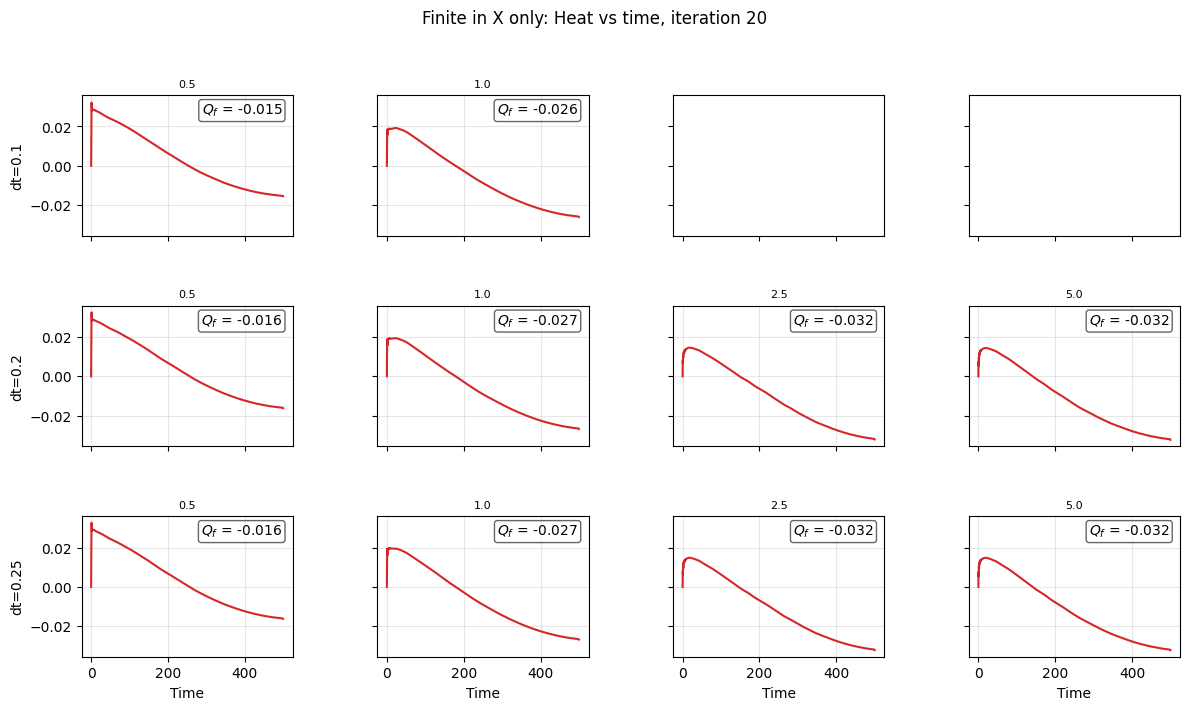

In [9]:
def get_heat(folder, iteration=-1):
    path = os.path.join(base_dir, folder, "500ps")
    opt_dict = load_opt_dict(path)
    if opt_dict is None:
        return None
    
    if iteration == -1:
        # use the final iteration
        iteration = len(opt_dict["log"]) - 1

    if "full heats" not in opt_dict["log"][iteration]:
        print(f"No heat data in {folder} at iteration {iteration}")
        return None

    return np.array(opt_dict["log"][iteration]["full heats"])


def plot_heat_grid(control_dict, title_prefix, iteration=-1):
    dts = sorted(control_dict.keys())

    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3*ncols, 2.4*nrows),
                             sharex=True, sharey=True)

    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)

    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt],
                             key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):

            heat = get_heat(folder, iteration)

            ax = axes[i, j]
            if heat is None:
                continue

            t = np.linspace(0, t_prot, len(heat))
            ax.plot(t, heat, color="C3")

            ax.set_title(f"{bounds}", fontsize=8)
            if i == nrows - 1:
                ax.set_xlabel("Time")
            if j == 0:
                ax.set_ylabel(f"dt={dt}")

            ax.grid(alpha=0.3)

            final_heat = heat[-1]

            ax.text(
                0.95, 0.95,
                f"$Q_f$ = {final_heat:.3f}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6)
            )

        

    plt.suptitle(f"{title_prefix}: Heat vs time, iteration {iteration}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0.5, wspace=0.4)
    plt.show()

plot_heat_grid(x_only, "Finite in X only", iteration=20)